# 🔍 TRANSFORMER / BERT 실습

1. Self-Attention을 numpy로 직접 구현해보기
2. 실제 BERT 모델로 attention을 시각화하고 관찰하기

## 0. 환경 준비

In [8]:
!pip install -q transformers torch matplotlib seaborn

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

---
## Part 1. Self-Attention 직접 구현해보기

**핵심 수식**

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

우리는 "Cats are very independent animals" 라는 문장을 6개의 토큰으로 나눴다고 가정하고, 각 토큰을 8차원 벡터(임베딩)로 표현했다고 가정합니다.

아래 `TODO` 부분을 채워보세요!

In [10]:
tokens = ['Cats', 'are', 'very', 'independent', 'animals', '[EOS]']

seq_len = len(tokens)
d_model = 8   # 임베딩 차원
d_k = 8       # Q, K, V 차원 (간단히 동일하게 설정)

# 토큰 임베딩 (실제로는 학습되지만, 여기선 랜덤 벡터로 대체)
X = np.random.randn(seq_len, d_model)

# Q, K, V를 만들기 위한 가중치 행렬 (실제로는 학습되는 파라미터)
Wq = np.random.randn(d_model, d_k) * 0.1
Wk = np.random.randn(d_model, d_k) * 0.1
Wv = np.random.randn(d_model, d_k) * 0.1

print('X shape:', X.shape)


X shape: (6, 8)


In [11]:
Q = X @ Wq
K = X @ Wk
V = X @ Wv

print('Q shape:', Q.shape if Q is not None else 'TODO')

Q shape: (6, 8)


In [12]:
# TODO 2: attention score를 계산해보세요
# 공식: scores = Q @ K.T / sqrt(d_k)
# 힌트: 전치(transpose)는 K.T, 제곱근은 np.sqrt() 사용

scores = Q @ K.T / np.sqrt(d_k)

print('scores shape:', scores.shape if scores is not None else 'TODO')

scores shape: (6, 6)


In [13]:
# TODO 3: softmax를 적용해서 attention weight를 만들어보세요
# 힌트: 각 행(row)의 합이 1이 되도록 axis=-1 기준으로 softmax를 적용해야 합니다

def softmax(x, axis=-1):
    e_x = np.exp(x - np.max(x, axis=axis, keepdims=True))
    return e_x / np.sum(e_x, axis=axis, keepdims=True)

attention_weights = softmax(scores)

# TODO 4: attention_weights와 V를 곱해서 최종 output을 만들어보세요
output = attention_weights @ V

print('output shape:', output.shape if output is not None else 'TODO')

output shape: (6, 8)


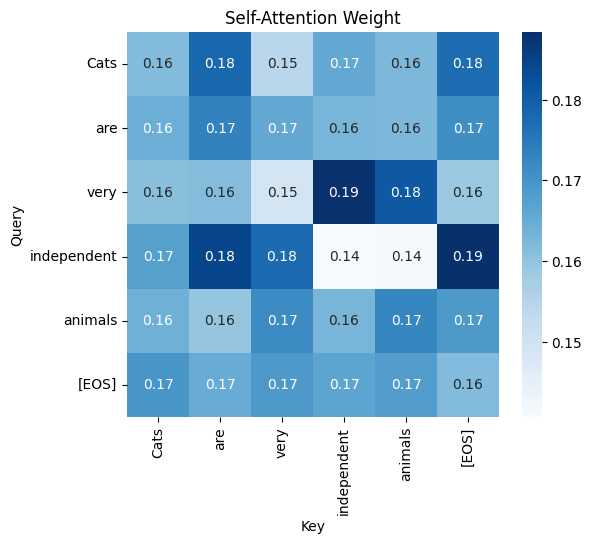

In [14]:
# 우리가 만든 attention weight를 시각화해봅시다
plt.figure(figsize=(6, 5))
sns.heatmap(attention_weights, xticklabels=tokens, yticklabels=tokens,
            annot=True, fmt='.2f', cmap='Blues')
plt.title('Self-Attention Weight')
plt.xlabel('Key')
plt.ylabel('Query')
plt.show()


### ✅ 정답

In [15]:
Q = X @ Wq
K = X @ Wk
V = X @ Wv

scores = Q @ K.T / np.sqrt(d_k)
attention_weights = softmax(scores)
output = attention_weights @ V

**생각해볼 질문**: 지금은 랜덤 가중치라 의미없는 패턴이 나옵니다. 실제 모델은 이 Wq, Wk, Wv를 학습을 통해 "의미있는" 값으로 채웁니다. Part 2에서 학습이 끝난 실제 모델은 어떤 패턴을 보이는지 확인해봅시다.

---
## Part 2. 실제 BERT 모델의 Attention 시각화

이번엔 실제로 학습된 다국어 BERT 모델(`bert-base-multilingual-cased`)을 불러와서, 한국어 문장을 넣고 attention이 어떻게 나오는지 확인해봅니다.

In [16]:
import torch
from transformers import AutoTokenizer, AutoModel

model_name = 'bert-base-multilingual-cased'
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name, output_attentions=True)
model.eval()

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  714MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(119547, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
 

In [21]:
# 여기 문장을 자유롭게 바꿔보세요!
sentence = 'I really love my hamster'

inputs = tokenizer(sentence, return_tensors='pt')
with torch.no_grad():
    outputs = model(**inputs)

attentions = outputs.attentions  # (layer 개수) 튜플, 각 원소 shape: (batch, head, seq, seq)
tokens_bert = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

print('레이어 개수:', len(attentions))
print('헤드 개수:', attentions[0].shape[1])
print('토큰:', tokens_bert)


레이어 개수: 12
헤드 개수: 12
토큰: ['[CLS]', 'I', 'really', 'love', 'my', 'ham', '##ster', '[SEP]']


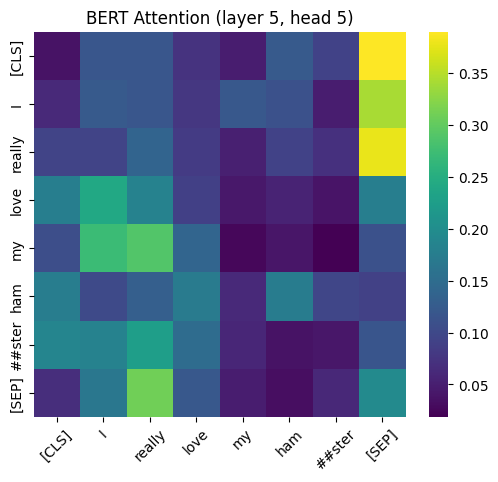

In [22]:
# 특정 레이어 / 특정 헤드의 attention을 시각화
layer = 5   # 0 ~ 11 사이 값으로 바꿔보세요
head = 5    # 0 ~ 11 사이 값으로 바꿔보세요

attn = attentions[layer][0, head].numpy()

plt.figure(figsize=(6, 5))
sns.heatmap(attn, xticklabels=tokens_bert, yticklabels=tokens_bert, cmap='viridis')
plt.title(f'BERT Attention (layer {layer}, head {head})')
plt.xticks(rotation=45)
plt.show()


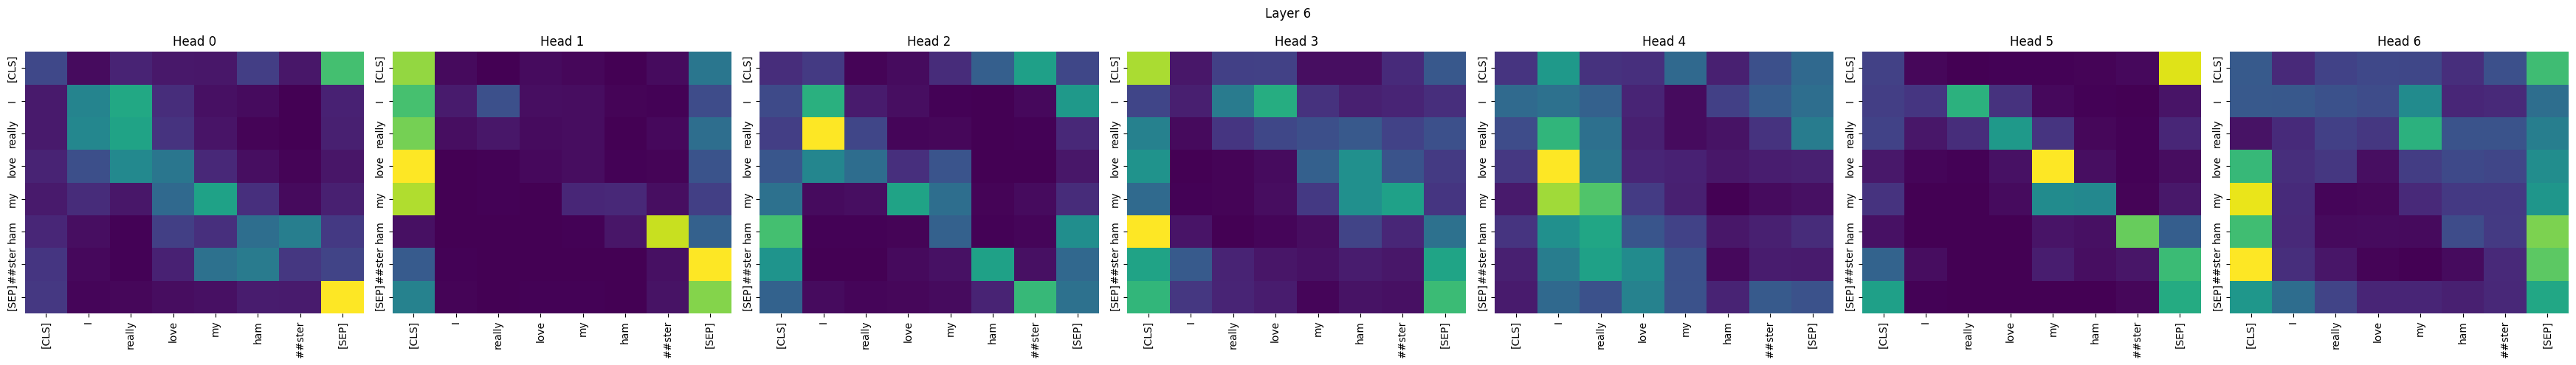

In [24]:
# 여러 헤드를 한번에 비교해보기 (같은 레이어, 여러 헤드)
layer = 6
num_heads_to_show = 7

fig, axes = plt.subplots(1, num_heads_to_show, figsize=(5 * num_heads_to_show, 5))
for h in range(num_heads_to_show):
    attn = attentions[layer][0, h].numpy()
    sns.heatmap(attn, xticklabels=tokens_bert, yticklabels=tokens_bert,
                cmap='viridis', ax=axes[h], cbar=False)
    axes[h].set_title(f'Head {h}')
    axes[h].tick_params(axis='x', rotation=90)
plt.suptitle(f'Layer {layer}')
plt.tight_layout()
plt.show()


### 🎯 실습
1. `sentence` 변수를 자기가 원하는 문장으로 바꿔서 다시 실행해보세요.
2. `layer`, `head` 값을 바꿔가며 관찰해보세요. (레이어 0-11, 헤드 0-11)
3. 다음 중 하나를 찾아보세요:
   - 특정 단어가 자기 자신에게만 집중하는 head가 있나요?
   - 조사가 관련된 명사에 집중하는 head가 있나요?
   - [CLS] 토큰에 유독 attention이 몰리는 레이어/헤드가 있나요?

In [25]:
import numpy as np

print("=== 자기 자신(대각선)에 집중하는 head ===")
results_diag = []
for layer in range(12):
    for head in range(12):
        attn = attentions[layer][0, head].numpy()
        diag_mean = np.mean(np.diag(attn))
        results_diag.append((layer, head, diag_mean))

# 대각선 평균값 높은 순으로 정렬해서 상위 5개만
results_diag.sort(key=lambda x: -x[2])
for layer, head, val in results_diag[:5]:
    print(f"layer {layer}, head {head}: 대각선 평균 = {val:.3f}")

=== 자기 자신(대각선)에 집중하는 head ===
layer 11, head 8: 대각선 평균 = 0.825
layer 11, head 11: 대각선 평균 = 0.825
layer 11, head 1: 대각선 평균 = 0.816
layer 11, head 10: 대각선 평균 = 0.802
layer 3, head 9: 대각선 평균 = 0.789


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51665 (\N{HANGUL SYLLABLE JIB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


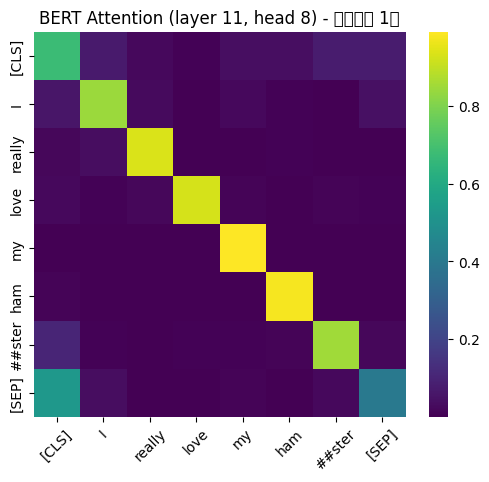

In [26]:
layer, head = 11, 8
attn = attentions[layer][0, head].numpy()

plt.figure(figsize=(6,5))
sns.heatmap(attn, xticklabels=tokens_bert, yticklabels=tokens_bert, cmap='viridis')
plt.title(f'BERT Attention (layer {layer}, head {head}) - 자기집중 1위')
plt.xticks(rotation=45)
plt.show()

---
## 정리

- Attention은 결국 "각 토큰이 문장 내 다른 토큰을 얼마나 참고할지"를 계산하는 것
- Q, K, V는 학습을 통해 의미있는 값을 갖게 되고, 그 결과로 head마다 서로 다른 문법적/의미적 패턴을 학습함
- 실제 Transformer는 이런 attention layer를 여러 개 쌓고, Feed-Forward, Residual/LayerNorm 등을 추가한 구조
- Transformer의 encoder 부분만 여러 층 쌓아서, 문장 전체를 양방향으로 보며 각 토큰의 의미를 학습하도록 만든 모델이 BERT